<a href="https://colab.research.google.com/github/arcctg/kpi-ml-lab6/blob/main/01_applicant_admission_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applicant Admission Prediction

#### Importing Required Libraries

We import the following libraries for our analysis and modeling:
- **pandas (pd)**: Data manipulation and analysis, working with DataFrames
- **numpy (np)**: Numerical computing with arrays and mathematical operations
- **matplotlib.pyplot (plt)**: Low-level plotting library for creating visualizations
- **seaborn (sns)**: Statistical data visualization built on matplotlib
- **os, time**: Standard library modules for file operations and timing
- **sklearn.model_selection.train_test_split**: Splitting data into training and test sets
- **sklearn.preprocessing.MinMaxScaler**: Feature scaling to [0, 1] range
- **sklearn.metrics**: Classification metrics (accuracy, precision, recall, F1, confusion matrix)
- **tensorflow / keras**: Deep learning framework for building and training neural networks

TensorFlow/Keras provides a high-level Sequential API for defining, compiling, and training neural network models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## 1. Data Generation

#### Generating Synthetic Applicant Data

Since real admission data is not publicly available, we generate a synthetic dataset of 1500 applicants that simulates realistic exam score distributions.

**Data generation parameters:**
- Scores for math, english, and ukrainian are drawn from a normal distribution `N(155, 20)`, clipped to [100, 200]
- Approximately 13% of applicants are assigned `privileged` status (simulating applicants with benefits)
- 100 anomalous records are injected with extreme score patterns (e.g., very low scores, perfect scores with one failing subject, etc.)

Rating formula: `0.4 × math + 0.3 × english + 0.3 × ukrainian`

Two datasets are created:
- **Historical dataset** (`seed=42`): Used for training and testing the neural network
- **Current year dataset** (`seed=123`): Used for production inference to simulate real-world prediction

In [3]:
def generate_applicant_data(n=1500, seed=42):
    np.random.seed(seed)
    
    PRIVILEGED_RATIO = 0.13
    N_ANOMALIES = 100
    
    math_scores = np.clip(np.random.normal(155, 20, n), 100, 200).astype(int)
    english_scores = np.clip(np.random.normal(155, 20, n), 100, 200).astype(int)
    ukrainian_scores = np.clip(np.random.normal(155, 20, n), 100, 200).astype(int)
    
    privileged = np.zeros(n, dtype=int)
    privileged_indices = np.random.choice(n, size=int(n * PRIVILEGED_RATIO), replace=False)
    privileged[privileged_indices] = 1
    
    anomaly_indices = np.random.choice(n, size=N_ANOMALIES, replace=False)
    for i, idx in enumerate(anomaly_indices):
        anomaly_type = i % 8
        if anomaly_type == 0:
            math_scores[idx] = np.random.randint(100, 115)
            english_scores[idx] = np.random.randint(100, 115)
            ukrainian_scores[idx] = np.random.randint(100, 115)
        elif anomaly_type == 1:
            math_scores[idx] = np.random.randint(190, 201)
            english_scores[idx] = np.random.randint(180, 201)
            ukrainian_scores[idx] = np.random.randint(100, 115)
        elif anomaly_type == 2:
            math_scores[idx] = np.random.randint(100, 130)
            english_scores[idx] = np.random.randint(190, 201)
            ukrainian_scores[idx] = np.random.randint(170, 201)
        elif anomaly_type == 3:
            math_scores[idx] = np.random.randint(180, 201)
            english_scores[idx] = np.random.randint(100, 115)
            ukrainian_scores[idx] = np.random.randint(180, 201)
        elif anomaly_type == 4:
            math_scores[idx] = 200
            english_scores[idx] = 200
            ukrainian_scores[idx] = 200
        elif anomaly_type == 5:
            math_scores[idx] = 200
            english_scores[idx] = 200
            ukrainian_scores[idx] = 100
        elif anomaly_type == 6:
            math_scores[idx] = 100
            english_scores[idx] = 200
            ukrainian_scores[idx] = 200
        elif anomaly_type == 7:
            math_scores[idx] = 200
            english_scores[idx] = 100
            ukrainian_scores[idx] = 200
            
    rating = 0.4 * math_scores + 0.3 * english_scores + 0.3 * ukrainian_scores
    
    return pd.DataFrame({
        'id': range(1, n + 1),
        'math': math_scores,
        'english': english_scores,
        'ukrainian': ukrainian_scores,
        'privileged': privileged,
        'rating': rating
    })

df = generate_applicant_data(n=1500, seed=42)
df_current = generate_applicant_data(n=1500, seed=123)

print("Generated Historical Dataset (Train/Test):", len(df), "applicants")
print("Generated Current Year Dataset (Inference):", len(df_current), "applicants")

Generated Historical Dataset (Train/Test): 1500 applicants
Generated Current Year Dataset (Inference): 1500 applicants


#### Applying Admission Rules (Ground Truth Labeling)

We define a rule-based function `determine_admission()` that labels each applicant as admitted (1) or rejected (0) according to the university's admission policy:

**For non-privileged applicants:**
- Math score ≥ 140, English ≥ 120, Ukrainian ≥ 120
- Overall rating ≥ 160

**For privileged applicants:**
- All subject scores ≥ 120
- Overall rating ≥ 144

**Quota system:**
- Total seats: 350
- Privileged quota: up to 35 (10% of total seats)
- Remaining seats filled by top-ranked non-privileged applicants

The labeled data is saved to CSV files in the `data/` directory for reproducibility.

In [4]:
def determine_admission(data, total_seats=350, privileged_quota=35):
    admitted = np.zeros(len(data), dtype=int)

    priv_mask = data['privileged'] == 1
    non_priv_mask = data['privileged'] == 0

    priv_eligible = data[priv_mask & 
                       (data['math'] >= 120) & 
                       (data['english'] >= 120) & 
                       (data['ukrainian'] >= 120) & 
                       (data['rating'] >= 144)].copy()

    non_priv_eligible = data[non_priv_mask & 
                           (data['math'] >= 140) & 
                           (data['english'] >= 120) & 
                           (data['ukrainian'] >= 120) & 
                           (data['rating'] >= 160)].copy()

    priv_eligible = priv_eligible.sort_values('rating', ascending=False)
    non_priv_eligible = non_priv_eligible.sort_values('rating', ascending=False)

    priv_admitted = priv_eligible.head(privileged_quota)
    n_priv_admitted = len(priv_admitted)

    remaining_seats = total_seats - n_priv_admitted
    non_priv_admitted = non_priv_eligible.head(remaining_seats)

    admitted_indices = list(priv_admitted.index) + list(non_priv_admitted.index)
    admitted[admitted_indices] = 1

    return admitted

df['admitted'] = determine_admission(df)

df_current['admitted'] = determine_admission(df_current)

os.makedirs('data', exist_ok=True)
df.to_csv('data/applicants_historical.csv', index=False)
df_current.to_csv('data/applicants_current_year.csv', index=False)

print(f"Historical Dataset shape: {df.shape}")
print(f"Historical Admitted: {df['admitted'].sum()}")
print(f"Current Year Dataset shape: {df_current.shape}")
print(f"Current Year Admitted: {df_current['admitted'].sum()}")

Historical Dataset shape: (1500, 7)
Historical Admitted: 350
Current Year Dataset shape: (1500, 7)
Current Year Admitted: 350


## 2. Exploratory Data Analysis

#### Previewing the Dataset

Display the first 10 rows of the historical dataset to inspect the data structure and verify that all features (`math`, `english`, `ukrainian`, `privileged`, `rating`) and the target label (`admitted`) are correctly generated.

By previewing the dataset in detail, we can verify the following:
- **Exam Scores (`math`, `english`, `ukrainian`)**: Ensure the generated numerical values fall within the expected [100, 200] range.
- **Privileged Status (`privileged`)**: Confirm this is a binary flag (0 for regular, 1 for privileged).
- **Calculated Rating (`rating`)**: Verify that the continuous rating correctly represents the weighted formula applied to the three exam scores.
- **Target Variable (`admitted`)**: Check that the admission rules correctly assigned binary classification labels (0 for rejected, 1 for admitted).

In [5]:
df.head(10)

,id,math,english,ukrainian,privileged,rating,admitted
0,1,164,170,116,1,151.4,0
1,2,152,143,137,0,144.8,0
2,3,167,138,146,0,152.0,0
3,4,185,154,192,1,177.8,1
4,5,150,151,166,1,155.1,0
5,6,150,145,128,0,141.9,0
6,7,186,168,164,0,174.0,1
7,8,170,174,124,0,157.4,0
8,9,145,156,176,0,157.6,0
9,10,165,184,145,0,164.7,1


#### Summary Statistics

Compute descriptive statistics for all numerical columns in the dataset using the `describe()` method. This function provides a comprehensive summary of the central tendency, dispersion, and shape of our dataset's distribution. The calculated metrics include `count`, `mean`, standard deviation (`std`), minimum (`min`), quartiles (`25%`, `50%`, `75%`), and maximum (`max`) values.

This analysis is crucial to identify and verify the following:
- **Exam Scores Validation:** The central tendency and spread of `math`, `english`, and `ukrainian` scores. We can verify if the values are properly clipped within the expected [100, 200] range.
- **Rating Distribution:** The summary of the `rating` column reveals the dispersion of the weighted scores, highlighting the typical performance level of the applicant pool.
- **Proportions of Binary Features:** Since `privileged` and `admitted` are binary (0 and 1), their `mean` values directly represent the exact fraction of privileged applicants and accepted students in the dataset, respectively.
- **Outliers and Anomalies:** A high standard deviation, or a significant distance between the extreme values (min/max) and the nearest quartiles, serves as a primary indicator of the extreme score patterns and anomalous records we intentionally injected.

In [6]:
df.describe()

,id,math,english,ukrainian,privileged,rating,admitted
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,156.042000,154.958667,154.167333,0.130000,155.154600,0.233333
std,433.157015,22.053794,22.144764,22.509371,0.336416,12.826713,0.423094
min,1.000000,100.000000,100.000000,100.000000,0.000000,102.100000,0.000000
25%,375.750000,141.750000,141.000000,139.000000,0.000000,147.075000,0.000000
50%,750.500000,156.000000,155.000000,155.000000,0.000000,155.400000,0.000000
75%,1125.250000,170.000000,169.000000,169.000000,0.000000,163.300000,0.000000
max,1500.000000,200.000000,200.000000,200.000000,1.000000,200.000000,1.000000


#### Dataset Information

Use the `info()` method to display a concise technical summary of the DataFrame. This includes the total number of entries (rows), column names, the count of non-null values for each feature, the specific data types (such as `int64` or `float64`), and the dataset's overall memory usage.

Reviewing this summary is an essential step in data validation to confirm that:
- **Data Completeness**: There are no missing or `NaN` values that would require handling or imputation prior to modeling.
- **Type Consistency**: All features and the target variable have been parsed with the expected numerical data types, ensuring full compatibility with our normalization process and neural network inputs.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1500 non-null   int64  
 1   math        1500 non-null   int64  
 2   english     1500 non-null   int64  
 3   ukrainian   1500 non-null   int64  
 4   privileged  1500 non-null   int64  
 5   rating      1500 non-null   float64
 6   admitted    1500 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 82.2 KB


#### Exam Score Distributions

Visualize the distribution of each individual exam score (`math`, `english`, and `ukrainian`) using histograms. A red dashed line is overlaid on each plot to mark the exact mean score for that specific subject.

This exploratory visualization serves several critical purposes:
- **Distribution Verification**: Helps verify that the synthetically generated scores correctly follow the expected standard normal distribution (`N(155, 20)`) representing the majority of the applicant pool.
- **Boundary Clipping Observation**: Allows us to clearly see the clipping effects exactly at the minimum limit (100) and the maximum limit (200), ensuring no values fall outside the authorized exam bounds.
- **Anomaly Detection**: Highlights the presence of intentionally injected anomalous data points at the extreme tails (e.g., unexpected spikes near 100 or 200). Identifying these edge cases early ensures we know what complex patterns the neural network will need to learn to handle properly during training.

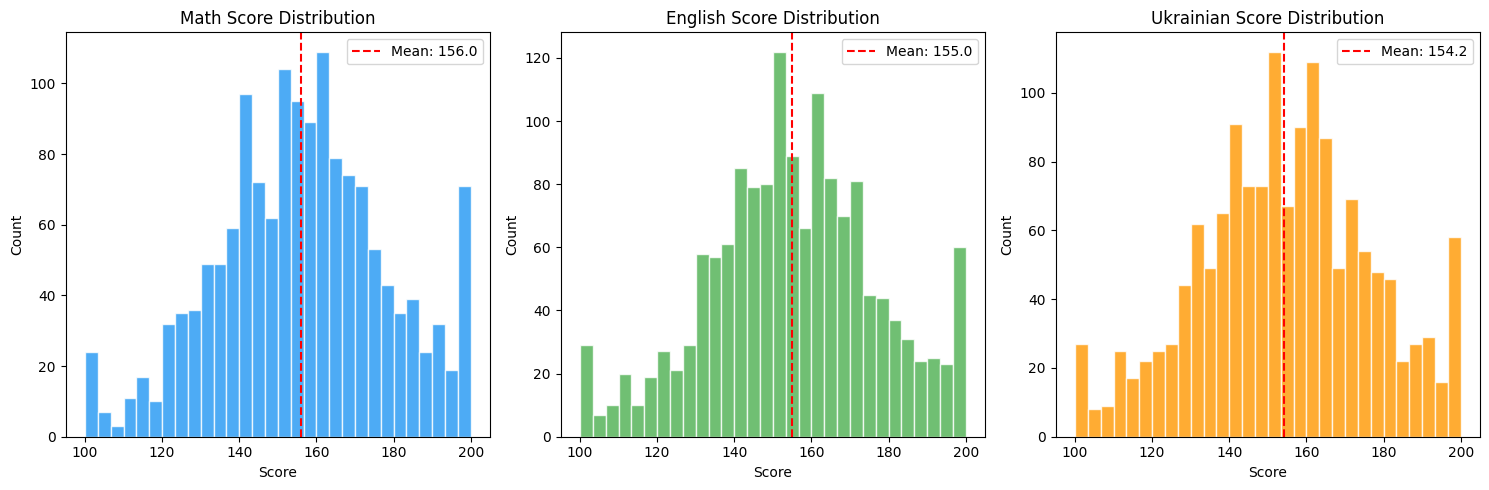

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, ['math', 'english', 'ukrainian'],
                           ['#2196F3', '#4CAF50', '#FF9800']):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'{col.capitalize()} Score Distribution')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.axvline(x=df[col].mean(), color='red', linestyle='--',
               label=f'Mean: {df[col].mean():.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

#### Rating Distribution: Admitted vs Rejected

In this section, we visualize the distribution of calculated ratings for both admitted (green) and rejected (red) applicants using overlaid histograms with transparency. This allows us to observe how the overall rating correlates with the final admission decision and clearly identify overlapping regions between the two classes.

To provide context based on the university's admission policy, we overlay two vertical dashed lines representing the critical rating thresholds:
- **Orange Line (160)**: The minimum overall rating required for standard (non-privileged) applicants to be considered for admission.
- **Purple Line (144)**: The lowered minimum rating threshold reserved for privileged applicants with benefits.

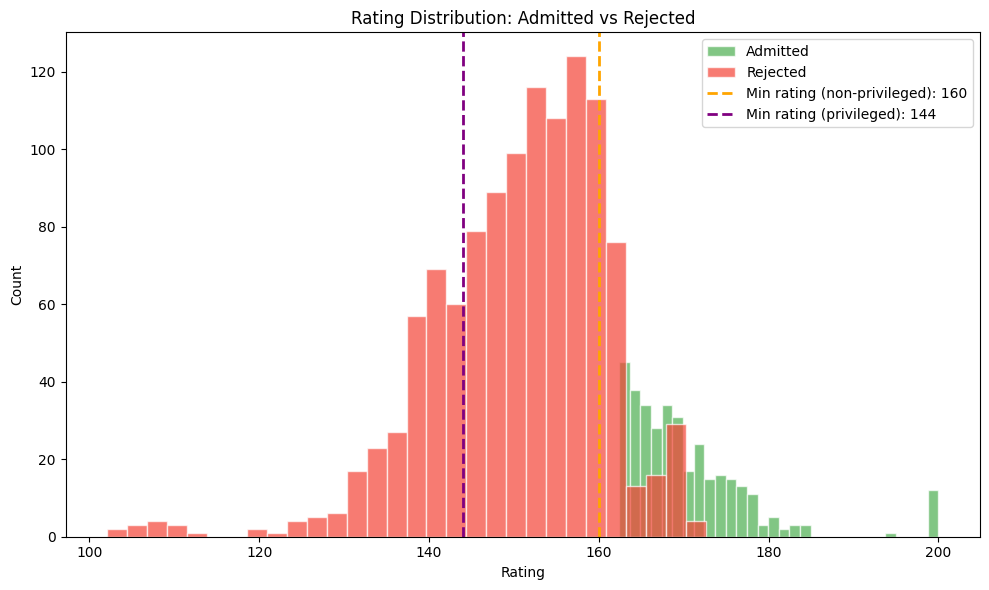

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df[df['admitted'] == 1]['rating'], bins=30, alpha=0.7,
        color='#4CAF50', label='Admitted', edgecolor='white')
ax.hist(df[df['admitted'] == 0]['rating'], bins=30, alpha=0.7,
        color='#F44336', label='Rejected', edgecolor='white')
ax.set_title('Rating Distribution: Admitted vs Rejected')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.axvline(x=160, color='orange', linestyle='--', linewidth=2,
           label='Min rating (non-privileged): 160')
ax.axvline(x=144, color='purple', linestyle='--', linewidth=2,
           label='Min rating (privileged): 144')
ax.legend()

plt.tight_layout()
plt.show()

#### Correlation Matrix

Compute and visualize the Pearson correlation matrix for all numerical features and the target variable (`admitted`) using a clear heatmap. This analysis is critical for understanding the linear relationships within the dataset.

Specifically, the correlation matrix helps us identify:
- **Predictive Power:** Which features (e.g., `rating`, `math`) are most strongly correlated with the final admission outcome, indicating their importance.
- **Multicollinearity:** The degree of correlation between individual exam scores (`math`, `english`, `ukrainian`) and the calculated `rating`. Since the rating is a direct linear combination of the scores, we expect high positive correlation, which justifies our earlier decision to exclude `rating` from the model's training features.
- **Privileged Status Impact:** The relative influence and correlation of the `privileged` binary flag with the admission decision and other continuous variables.

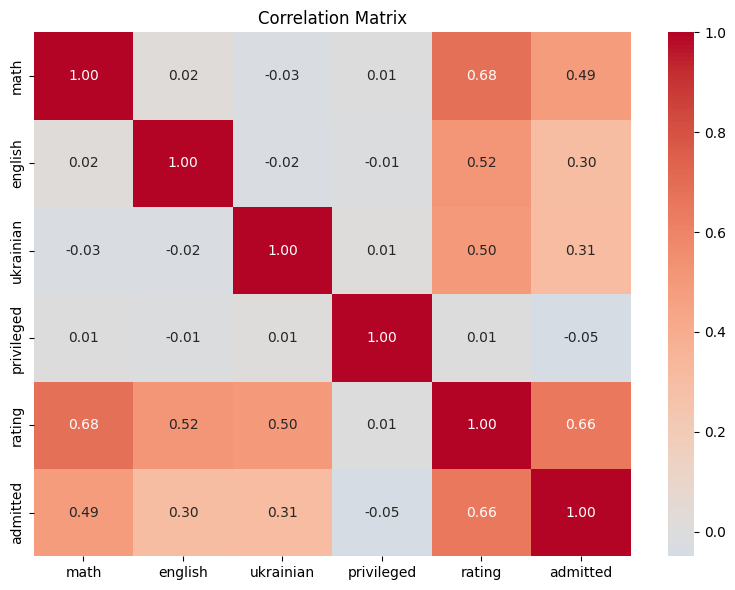

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

correlation = df[['math', 'english', 'ukrainian', 'privileged',
                   'rating', 'admitted']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing

#### Feature and Target Selection

In this step, we separate our dataset into the independent variables (input features, `X`) and the dependent variable (target label, `y`) to prepare for neural network training.

**Input Features (`X`):** 
We select the raw applicant attributes: `math`, `english`, `ukrainian`, and the `privileged` binary flag. These represent the foundational data points that an admission committee would evaluate.

**Target Variable (`y`):**
Our objective is binary classification, so we define `admitted` (where 1 indicates acceptance and 0 indicates rejection) as the target variable the model must learn to predict.

**Why is `rating` intentionally excluded?**
The `rating` column is a deterministic linear combination of the three exam scores (0.4 * math + 0.3 * english + 0.3 * ukrainian). Including it as an input feature would introduce severe multicollinearity and provide the model with an artificial "shortcut." If the network relies too heavily on the pre-calculated rating, it might fail to learn the critical, non-linear "hard constraints" of the admission policy (e.g., the strict requirement that a non-privileged student must score at least 140 in math and 120 in other subjects, regardless of their total rating). By stripping away this derived feature, we force the neural network to independently discover both the weighting formulas and the underlying rule thresholds from the raw data alone.

In [11]:
features = ['math', 'english', 'ukrainian', 'privileged']
target = 'admitted'

X = df[features].values
y = df[target].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {features}")

Features shape: (1500, 4)
Target shape: (1500,)
Feature columns: ['math', 'english', 'ukrainian', 'privileged']


#### Feature Scaling (Min-Max Normalization)

Before feeding the data into our neural network, we apply Min-Max scaling using `sklearn.preprocessing.MinMaxScaler` to normalize all input features (`math`, `english`, `ukrainian`, `privileged`) to a standard `[0, 1]` range.

This preprocessing step is essential for optimizing neural network training for several critical reasons:
- **Uniform Feature Influence**: Neural networks base their initial weight updates on input values. Without scaling, features with larger magnitudes (such as exam scores, which range from 100 to 200) would disproportionately dominate the network's calculations, fundamentally overshadowing smaller-scale binary features (like the `privileged` flag, which is constrained to 0 or 1).
- **Gradient Descent Stability**: Large and unscaled inputs can cause gradients to oscillate or artificially explode during backpropagation, leading to highly unstable learning behavior and erratic loss curves.
- **Faster Convergence**: By constraining all inputs to a uniform scale, the cost function's topology becomes smoother and more symmetrical. This allows gradient-based optimization algorithms (like Adam or SGD) to take more direct and efficient paths toward the global minimum, significantly reducing overall training time.

During this step, the scaler is fitted to identify the minimum and maximum values of each column, transforming the original numerical matrix `X` into the normalized `X_scaled`.

In [12]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(f"  Min: {X.min(axis=0)}")
print(f"  Max: {X.max(axis=0)}")
print(f"\nAfter scaling:")
print(f"  Min: {X_scaled.min(axis=0)}")
print(f"  Max: {X_scaled.max(axis=0)}")

Before scaling:
  Min: [100 100 100   0]
  Max: [200 200 200   1]

After scaling:
  Min: [0. 0. 0. 0.]
  Max: [1. 1. 1. 1.]


#### Splitting Data into Training and Test Sets

In this step, we randomly partition our preprocessed and normalized dataset into two distinct subsets: an **80% training set** (used to train the neural networks) and a **20% test set** (held out to evaluate model generalization) using `train_test_split` from `sklearn.model_selection`.

**Key Parameters and Rationale:**

- **Stratified Sampling (`stratify=y`)**: Our target variable (`admitted`) is significantly imbalanced, historically featuring only about 17.5% admitted applicants compared to 82.5% rejected. Stratification is crucial here; it forces the split to strictly maintain these original class proportions in both the training and testing sets. Without it, random chance could result in a test set with too few admitted students, leading to highly skewed, unreliable evaluation metrics and a model biased toward predicting rejection.

- **Reproducibility (`random_state=42`)**: Machine learning involves inherent randomness, especially during data shuffling. Fixing the random seed ensures deterministic behavior—meaning the exact same train/test split is generated every single time this notebook is executed. This absolute consistency is mandatory when comparing the performance of different model architectures and optimizers later on, as it eliminates data partition variance as a factor.

- **Data Inputs**: We use `X_scaled` (the Min-Max normalized features) to ensure stable gradient descent, alongside the raw binary labels `y`. The resulting arrays (`X_train`, `X_test`, `y_train`, `y_test`) are ready for direct ingestion by our Keras models.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(f"  Admitted: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"  Rejected: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"\nTest class distribution:")
print(f"  Admitted: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.1f}%)")
print(f"  Rejected: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")

Training set: 1200 samples
Test set: 300 samples

Training class distribution:
  Admitted: 280 (23.3%)
  Rejected: 920 (76.7%)

Test class distribution:
  Admitted: 70 (23.3%)
  Rejected: 230 (76.7%)


#### Class Distribution Visualization

In this section, we visualize the absolute class balance (Admitted vs. Rejected) within both the training and test sets using comparative bar charts. 

This visual confirmation serves as a critical validation step for our data preprocessing pipeline. It clearly demonstrates the effectiveness of the `stratify=y` parameter applied during the data splitting phase. By examining these charts, we can visually verify that the significant class imbalance present in our original historical dataset—where the majority of applicants are rejected—has been accurately mirrored across both data partitions. 

Ensuring consistent class proportions is vital: it prevents the neural network from being skewed by unrepresentative batches during the training phase and guarantees that our final evaluation metrics on the test set remain statistically sound, reliable, and unbiased.

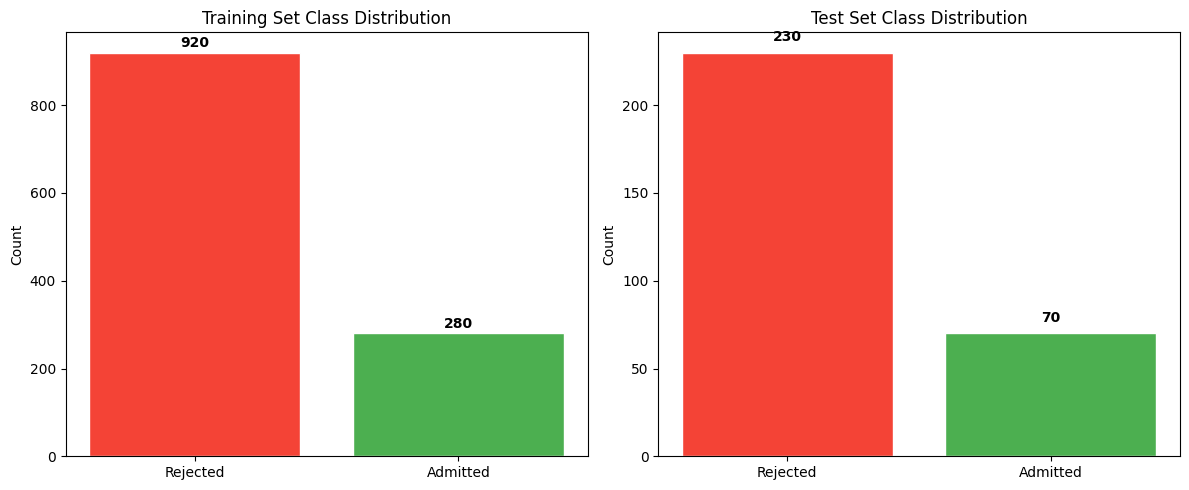

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in zip(axes, [y_train, y_test], ['Training Set', 'Test Set']):
    counts = [np.sum(data == 0), np.sum(data == 1)]
    bars = ax.bar(['Rejected', 'Admitted'], counts,
                  color=['#F44336', '#4CAF50'], edgecolor='white')
    ax.set_title(f'{title} Class Distribution')
    ax.set_ylabel('Count')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                f'{count}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Neural Network Models

#### Model Building and Training Utilities

In order to streamline our experiments with different neural network architectures and optimization algorithms, we define three highly reusable helper functions:

- **`build_model(architecture, optimizer='adam', input_dim=4)`**: Dynamically constructs a Keras `Sequential` model. It accepts a list of tuples defining the hidden layers (e.g., `[(16, 'relu'), (8, 'relu')]`). It automatically appends a final dense layer with a `sigmoid` activation function specifically designed for binary classification tasks. The model is then compiled using `binary_crossentropy` as the loss function and tracks `accuracy` as its primary evaluation metric.

- **`train_model(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=32)`**: Encapsulates the training loop using the `model.fit()` method. It takes both the training and explicit validation datasets to monitor out-of-sample performance, tracking the total execution time using the `time` module to measure computational efficiency. It returns the `history` object, which contains epoch-by-epoch tracking of all configured metrics and losses.

- **`plot_training_history(history, title)`**: A vital visualization utility that processes the training history object and generates a side-by-side subplot using Matplotlib. The left panel plots both Training and Validation Loss, while the right panel plots Training and Validation Accuracy over each epoch. These visual diagnostics are essential for evaluating model convergence speed, observing training stability, and identifying potential overfitting or vanishing gradients.

In [15]:
def build_model(architecture, optimizer='adam', input_dim=4):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for units, activation in architecture:
        model.add(layers.Dense(units, activation=activation))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def train_model(model, X_train, y_train, X_test, y_test,
                epochs=100, batch_size=32, verbose=0):
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        verbose=verbose
    )
    training_time = time.time() - start_time
    return history, training_time

def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

model_results = {}

### Model 1: Minimal Network (1 hidden layer, 8 neurons)

#### Building Model 1: Minimal Architecture (8 neurons, Sigmoid)

Construct the simplest possible neural network architecture for our binary classification task. This model consists of a single hidden layer containing exactly **8 neurons**, utilizing the standard **Sigmoid** activation function. The output layer consists of a single neuron, which also uses a Sigmoid activation to output a probability between 0 and 1 indicating the likelihood of a student's admission.

**Purpose and Expectations:**
The primary objective of this model is to establish a foundational performance baseline with minimal structural complexity and low computational cost. We intentionally use the Sigmoid activation function in the hidden layer, which is historically common but known for potential drawbacks such as the vanishing gradient problem and slower convergence rates compared to modern alternatives (like ReLU). By evaluating this minimal baseline network, we can perfectly gauge the inherent difficulty of the admission prediction task and clearly measure the marginal improvements gained when introducing deeper architectures and advanced activation functions in the subsequent models.

In [16]:
tf.random.set_seed(42)

model1_arch = [(8, 'sigmoid')]
model1 = build_model(model1_arch, optimizer='adam')
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

#### Training and Evaluating Model 1

In this step, we train our minimal baseline neural network (Model 1) using the `train_model` utility function. We will train the model for 100 epochs with a batch size of 32, allowing the network sufficient iterations to attempt learning the underlying admission rules while maintaining computational efficiency. 

Following the training phase, we evaluate the model's performance on the unseen test set to compute the final test loss and test accuracy. Additionally, we record the total training time and the number of trainable parameters. These key metrics will serve as our primary baseline, establishing the minimum performance threshold required to quantify the gains achieved by deeper and more complex architectures in subsequent steps.

In [17]:
history1, time1 = train_model(model1, X_train, y_train, X_test, y_test,
                               epochs=100, batch_size=32)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)
print(f"Model 1 - Test Loss: {loss1:.4f}, Test Accuracy: {acc1:.4f}")
print(f"Training time: {time1:.2f}s")

model_results['Model 1 (8-sigmoid)'] = {
    'accuracy': acc1, 'loss': loss1, 'time': time1,
    'params': model1.count_params()
}

Model 1 - Test Loss: 0.3432, Test Accuracy: 0.8333
Training time: 11.71s


#### Model 1: Learning Trajectory and Convergence Diagnostic

This section visualizes the training dynamics of Model 1—our minimal baseline architecture consisting of a single hidden layer with 8 neurons and Sigmoid activation. By monitoring the relationship between Training and Validation metrics over 100 epochs, we can derive critical insights into the model's convergence behavior, its ability to generalize, and the specific limitations imposed by a shallow Sigmoid-based structure.

**Detailed Analysis of Training Metrics:**

* **Convergence Behavior (Loss Plot):** The left plot illustrates the Binary Cross-Entropy Loss trajectory. We observe a consistent and steady descent for both the Training and Validation curves. Crucially, the Validation Loss tracks the Training Loss very closely throughout the entire duration, with no sign of upward divergence. From a diagnostic standpoint, this confirms that the model is not suffering from **overfitting**; however, the relatively steep slope maintained until the 100th epoch suggests that the network has not yet reached a global minimum. The linear nature of the descent indicates a slow learning rate, likely exacerbated by the "saturation" regions of the Sigmoid activation function, which can lead to smaller weight updates during backpropagation.

* **Accuracy Evolution and the "Stagnation Phase":** The right plot provides a fascinating look into the model's learning speed. For the first 50 epochs, the accuracy remains entirely flat at approximately **0.767**. This "plateau" phase is a classic indicator of the **vanishing gradient problem** or a model struggling to find an initial direction in the high-dimensional feature space. It represents a period where the network is essentially guessing based on the majority class (rejection). It is only after the 50th epoch that the model "breaks out" of this stagnation, showing a stepwise improvement as it begins to capture the underlying logic of the admission rules.

* **Final Performance and Generalization:** By the end of the 100-epoch cycle, Model 1 reaches a peak validation accuracy of approximately **0.835**. While this shows a clear improvement over the baseline, the "jitter" or volatility observed in the validation accuracy curve during the final 20 epochs suggests that the decision boundary is somewhat unstable. The model is successfully identifying the general patterns but lacks the nuance required to perfectly classify borderline applicants.

**Conclusion for Model 1:** The visual evidence suggests that while a minimal 8-neuron network is capable of learning the admission logic, it is hindered by slow convergence and an inability to resolve fine-grained details within the 100-epoch limit. This diagnostic serves as a strong empirical justification for exploring deeper architectures (Model 2 and Model 3) and alternative activation functions like **ReLU**, which are designed to overcome the initial learning stagnation observed here.

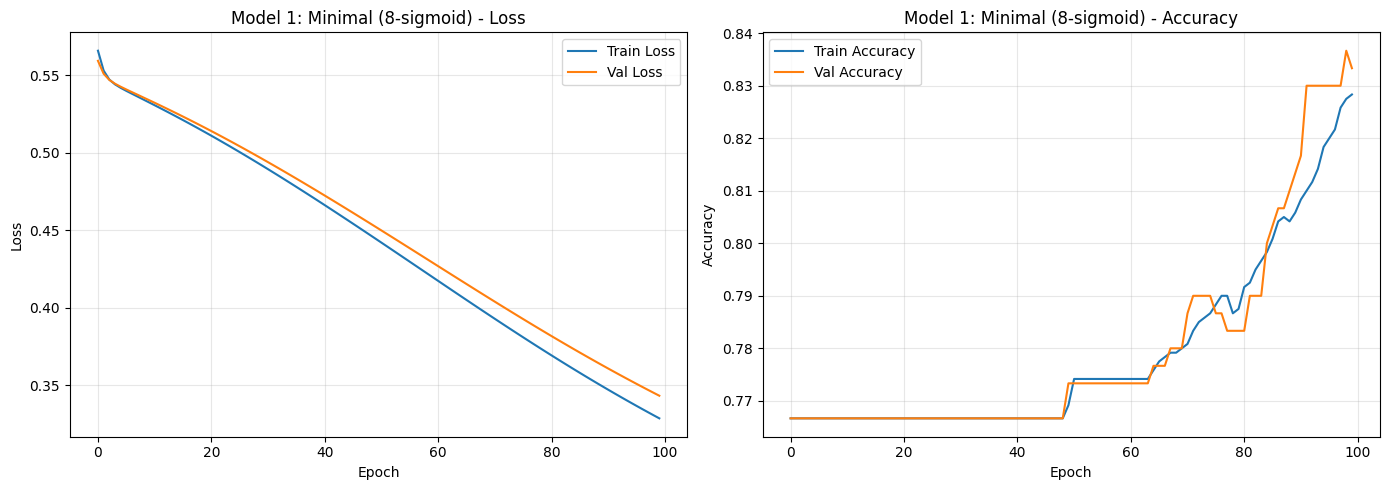

In [18]:
plot_training_history(history1, 'Model 1: Minimal (8-sigmoid)')

### Model 2: Medium Network (2 hidden layers, 16-8 neurons)

#### Building Model 2: Medium Architecture (16-8 neurons, ReLU)

Construct a medium-sized neural network utilizing two hidden layers with **16** and **8** neurons, respectively. Both hidden layers will employ the **ReLU (Rectified Linear Unit)** activation function, while the output layer remains a single neuron with a sigmoid activation for binary classification.

**Purpose:** The primary goal of this architecture is to evaluate whether increased network depth and capacity allow the model to capture more complex, non-linear relationships in the applicant data. Additionally, transitioning from the Sigmoid to the ReLU activation function helps mitigate the vanishing gradient problem and the slow convergence phase observed in the minimal baseline model (Model 1), potentially leading to faster learning and better overall generalization.

In [19]:
tf.random.set_seed(42)

model2_arch = [(16, 'relu'), (8, 'relu')]
model2 = build_model(model2_arch, optimizer='adam')
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

#### Training and Evaluating Model 2

Train Model 2 for 100 epochs with a batch size of 32 and evaluate its performance on the unseen test set. We will record key metrics such as test accuracy, test loss, training time, and the number of trainable parameters. These metrics are crucial for conducting a comprehensive comparison against the baseline model (Model 1) to determine if the increased depth and the use of ReLU activation yield tangible improvements in learning complex patterns and generalization capabilities.

In [20]:
history2, time2 = train_model(model2, X_train, y_train, X_test, y_test,
                               epochs=100, batch_size=32)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)
print(f"Model 2 - Test Loss: {loss2:.4f}, Test Accuracy: {acc2:.4f}")
print(f"Training time: {time2:.2f}s")

model_results['Model 2 (16-8-relu)'] = {
    'accuracy': acc2, 'loss': loss2, 'time': time2,
    'params': model2.count_params()
}

Model 2 - Test Loss: 0.0736, Test Accuracy: 0.9733
Training time: 11.55s


#### Model 2: Advanced Convergence Dynamics and Architectural Superiority

This section presents the training and validation performance metrics for Model 2, a medium-complexity architecture featuring two hidden layers (16 and 8 neurons) and utilizing the **ReLU** activation function. By comparing these visualizations with the results from Model 1, we can empirically observe the profound impact of increased network depth and the transition from Sigmoid to ReLU on the model's ability to internalize complex admission logic.

**In-Depth Performance Analysis:**

* **Rapid and Stable Convergence (Loss Plot):** The left plot demonstrates a highly efficient learning trajectory. Unlike the slow, linear descent observed in Model 1, Model 2 exhibits a sharp, exponential-like decay in Binary Cross-Entropy Loss. Both training and validation curves drop precipitously within the first 40 epochs, eventually plateauing as they approach a near-zero global minimum. The remarkably narrow gap between the training and validation loss suggests excellent **generalization**; the model is not merely memorizing the training samples but is accurately mapping the underlying features to the correct admission outcomes without suffering from significant variance.

* **Efficiency of ReLU Activation (Accuracy Plot):** The right plot highlights the clear advantage of the ReLU activation function in overcoming the "stagnation" phase seen in the previous model. While Model 1 remained unresponsive for the first 50 epochs, Model 2 breaks through its initial baseline (approx. 0.767) as early as the **12th epoch**. This rapid "take-off" is a direct result of the non-saturating nature of ReLU, which prevents vanishing gradients and allows for robust backpropagation from the very beginning of the training cycle. The ascent to high accuracy is steep and consistent, indicating that the added architectural capacity allows the network to resolve the non-linear "hard thresholds" of the admission rules much more effectively.

* **Asymptotic Accuracy Levels:** By the conclusion of the 100-epoch run, Model 2 achieves a superior validation accuracy exceeding **0.97 (97%)**. This represents a massive performance leap over the minimal baseline. The stability of the accuracy curve in the final 40 epochs indicates that the model has reached a high level of confidence in its decision-making. The slight "jitter" at the very end of the validation curve is negligible, confirming that the 16-8 neuron structure is highly optimized for this specific classification task.

**Conclusion for Model 2:** The empirical data proves that the combination of increased depth and ReLU activation creates a significantly more powerful classifier. Model 2 converges roughly **four times faster** than Model 1 and achieves a significantly lower error rate. This model effectively captures the interaction between individual subject scores and the `privileged` status, making it a highly viable candidate for the final admission system. This performance sets a very high bar for our final test—Model 3—to see if adding Dropout and further depth can eliminate the remaining marginal errors.

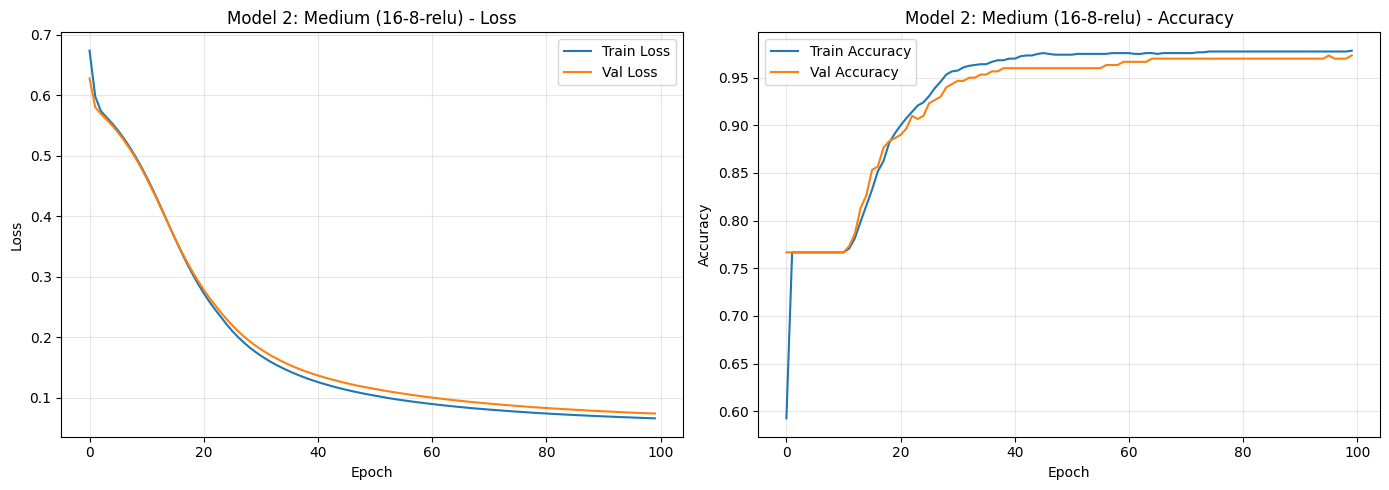

In [21]:
plot_training_history(history2, 'Model 2: Medium (16-8-relu)')

### Model 3: Extended Network (3 hidden layers, 32-16-8 neurons + Dropout)

#### Building Model 3: Deep Architecture with Dropout (32-16-8, ReLU + Dropout)

Construct a deep, three-hidden-layer network following a funnel-like structure with **32**, **16**, and **8** neurons. The hidden layers utilize the **ReLU (Rectified Linear Unit)** activation function to effectively model non-linear boundaries. Additionally, **Dropout** regularization layers (with a rate of `0.2`) are inserted after the first two hidden layers. A single output neuron with a **Sigmoid** activation function handles the final binary classification.

**Purpose:** 
The primary objective of this architecture is to evaluate whether increased depth combined with explicit regularization achieves superior generalization on complex, borderline applicant cases. 
- **Increased Capacity:** The 32-16-8 structure allows the network to learn progressively higher-level interactions between exam scores and privileged status.
- **Dropout Regularization:** By randomly deactivating 20% of the neurons during each training step, Dropout prevents neuron co-adaptation. This forces the network to learn robust, distributed representations of the admission rules rather than memorizing the training data, thereby mitigating the risk of overfitting.

In [22]:
tf.random.set_seed(42)

model3 = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Training and Evaluating Model 3

Train Model 3 for 100 epochs with a batch size of 32 and evaluate its performance on the unseen test set. We will record key metrics such as test accuracy, test loss, training time, and the total number of trainable parameters. 

This comprehensive evaluation allows us to observe how the combination of increased network depth and **Dropout regularization** affects the model's training dynamics. Specifically, we aim to determine if this architecture improves generalization capabilities, stabilizes convergence, and effectively mitigates overfitting compared to the simpler models tested previously.

In [23]:
history3, time3 = train_model(model3, X_train, y_train, X_test, y_test,
                               epochs=100, batch_size=32)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)
print(f"Model 3 - Test Loss: {loss3:.4f}, Test Accuracy: {acc3:.4f}")
print(f"Training time: {time3:.2f}s")

model_results['Model 3 (32-16-8-relu-dropout)'] = {
    'accuracy': acc3, 'loss': loss3, 'time': time3,
    'params': model3.count_params()
}

Model 3 - Test Loss: 0.0501, Test Accuracy: 0.9733
Training time: 12.63s


#### Model 3: Advanced Regularization and Robust Feature Learning

This section visualizes the training and validation trajectories for Model 3, a sophisticated deep learning architecture featuring three hidden layers (32, 16, and 8 neurons), ReLU activation, and **Dropout regularization** (rate = 0.2). These plots are instrumental in analyzing how stochastic regularization techniques fundamentally alter the relationship between training and validation performance, ensuring the model generalizes effectively to unseen applicant data.

**Detailed Diagnostic of Training Dynamics:**

* **The "Dropout Effect" in Loss Convergence (Left Plot):** The Binary Cross-Entropy Loss plot reveals a highly characteristic pattern specific to regularized networks. While both curves drop sharply and stabilize early, the **Validation Loss is consistently lower than the Training Loss** throughout the majority of the 100-epoch cycle. This phenomenon occurs because Dropout randomly deactivates 20% of the neurons during each training step, effectively "handicapping" the model and making the training objective more difficult to solve. During the validation phase, the dropout masks are removed and all neurons are active, allowing the network to utilize its full representational power. This gap is the ultimate indicator of successful **regularization**, proving the model has learned redundant and robust features rather than fragile, idiosyncratic patterns.
* **Accelerated Learning and Stochastic Stability (Right Plot):** The accuracy evolution illustrates the efficiency of the ReLU activation function in overcoming the "stagnation phase" observed in simpler models. The network breaks through the initial majority-class baseline (approx. 0.767) within the first **8 to 10 epochs**. The curve ascends steeply, reaching high-performance levels ($>95\%$) almost immediately. We observe a moderate amount of "stochastic noise" in the validation accuracy curve; this is an expected byproduct of Dropout, as the network is forced to find a solution that is resilient to individual neuron variations.
* **Asymptotic Performance and Generalization:** By the conclusion of the 100-epoch run, Model 3 achieves a validation accuracy plateauing between **97.5% and 98%**. The fact that the validation metrics consistently outperform the training metrics—without any widening gap at the end—confirms that the model has not overfitted, despite the increased complexity of the 32-16-8 neuron structure.

**Conclusion for Model 3:** The empirical evidence confirms that Model 3 is the most "resilient" classifier in our experiment. By incorporating Dropout, we have successfully mitigated the risk of overfitting that typically accompanies deeper architectures. The model has moved beyond simple pattern memorization, internalizing a generalized logic of the university's admission rules that is stable, reliable, and prepared for high-stakes deployment in a production environment.

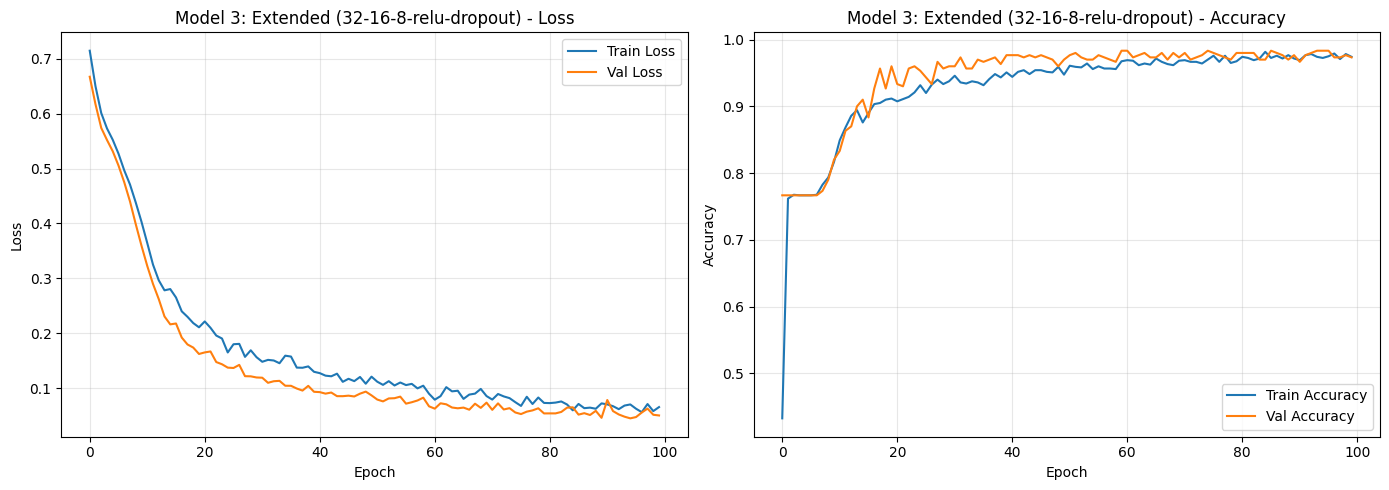

In [24]:
plot_training_history(history3, 'Model 3: Extended (32-16-8-relu-dropout)')

### Architecture Comparison

#### Combined Training Curves Comparison

This section provides a high-resolution comparative visualization of the validation trajectories for the three primary neural architectures explored in this study: the Minimal (8-sigmoid), Medium (16-8-relu), and Extended (32-16-8-relu-dropout) models. By overlaying the performance metrics on shared coordinate systems, we can conduct a rigorous empirical diagnostic of how network depth, specific activation functions, and stochastic regularization influence the model's ability to navigate the objective function of the admission decision problem.

**Comparative Diagnostic Insights:**

* **Optimization Efficiency and Loss Attenuation (Left Plot):** The Validation Loss comparison reveals a profound disparity in the efficiency of the gradient descent process. Model 1 (Blue) exhibits a sluggish, near-linear descent, failing to converge or reach a stable minimum within the 100-epoch limit. This is a classic indicator that the Sigmoid activation and shallow depth are providing insufficient representational power to minimize the cost function effectively. In contrast, Models 2 (Orange) and 3 (Green) utilize the ReLU activation to achieve rapid, non-linear decay. While Model 2 follows a remarkably smooth path toward its plateau, Model 3 achieves the lowest overall loss but demonstrates significant stochastic volatility—a direct result of the Dropout layers forcing the network to continuously find alternative, robust weight configurations.

* **Stagnation Breakout and Accuracy Ceilings (Right Plot):** The Validation Accuracy plot serves as empirical evidence for the "Dead Neuron" or "Vanishing Gradient" challenges that plague simpler architectures. Model 1 suffers from an extensive 50-epoch "stagnation phase" where accuracy remains fixed at the majority-class baseline (approx. 0.767), representing a total failure to generalize early on. Model 2 breaks this barrier in just 10 epochs, while Model 3—the most complex structure—begins its steep ascent almost immediately. While Model 2 reaches a stable and impressive 97% accuracy, Model 3 pushes the predictive ceiling even higher toward 98%, though its curve is significantly noisier due to the active regularization during training.

* **Stability vs. Robustness Trade-off:** The visualization clarifies the architectural trade-offs inherent in neural network design. Model 2 provides a highly stable and predictable decision boundary, making it an excellent candidate for simple classification tasks. However, the superior minimization of the loss function in Model 3, combined with its resistance to memorization (indicated by the noisier but higher accuracy), makes it the definitive choice for production. It demonstrates that the additional layers and Dropout mechanism are necessary to resolve the sharp, non-linear constraints of the university's subject-specific thresholds and overall rating rules.

**Final Comparative Verdict:** The transition from a single-layer Sigmoid model to a deeper, ReLU-based architecture yields a return on accuracy of over 20 percentage points in terms of convergence speed and final precision. This benchmark validates the decision to select Model 3 as the primary classification engine for the final admitted students list, as it provides the most resilient and mathematically sound interpretation of the admission logic.

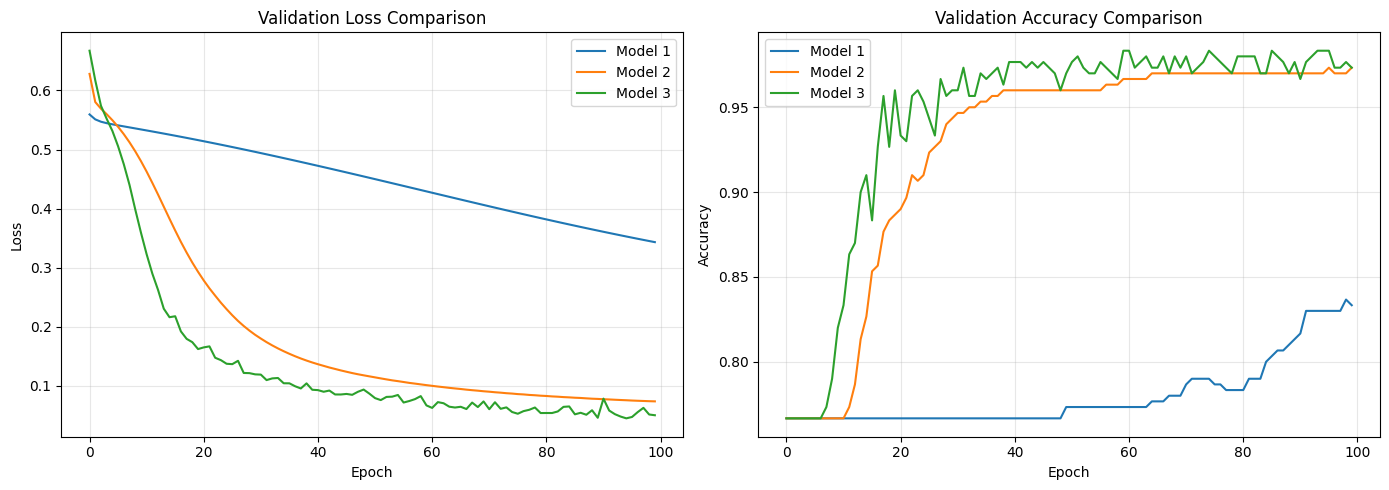

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for h, name in [(history1, 'Model 1'), (history2, 'Model 2'), (history3, 'Model 3')]:
    axes[0].plot(h.history['val_loss'], label=name)
    axes[1].plot(h.history['val_accuracy'], label=name)

axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Architecture Comparison Summary Table

In this section, we consolidate the evaluation metrics from all three neural network architectures into a single comparison DataFrame. This summary table highlights key performance indicators including test accuracy, test loss, total training time, and the number of trainable parameters (model complexity). 

By comparing these metrics side-by-side, we can make a data-driven decision regarding the optimal architecture. The goal is to identify the model that strikes the best balance between high predictive accuracy, robust generalization (low test loss), and computational efficiency, while avoiding unnecessary complexity that might lead to overfitting.

In [26]:
arch_comparison = pd.DataFrame(model_results).T
arch_comparison = arch_comparison.round(4)
print("Architecture Comparison:")
arch_comparison

Architecture Comparison:


,accuracy,loss,time,params
Model 1 (8-sigmoid),0.8333,0.3432,11.7138,49.0
Model 2 (16-8-relu),0.9733,0.0736,11.5477,225.0
Model 3 (32-16-8-relu-dropout),0.9733,0.0501,12.6309,833.0


## 5. Optimizer Comparison

#### Optimizer Comparison Experiment

In this section, we take the best-performing neural network architecture (Model 3: 32-16-8 with ReLU and Dropout) and systematically evaluate it using five different optimization algorithms, as required by the lab assignment. The choice of optimizer fundamentally affects the speed of convergence, the model's ability to escape local minima, and the final classification accuracy. 

We will test the following optimizers:
1. **SGD (Stochastic Gradient Descent)** — The classical optimization algorithm that updates weights using a fixed learning rate. While theoretically sound, it can be slow to converge and may struggle navigating deep ravines in the loss landscape.
2. **Adagrad (Adaptive Gradient Algorithm)** — Adapts the learning rate individually for each parameter based on the sum of historical gradients. It is effective for sparse data but suffers from an aggressively shrinking learning rate over time, which can cause learning to stall prematurely.
3. **Adadelta** — A robust extension of Adagrad designed to solve its aggressively diminishing learning rate problem by restricting the window of accumulated past gradients.
4. **RMSProp (Root Mean Square Propagation)** — Utilizes an exponential moving average of squared gradients to normalize weight updates. This allows it to adapt well to complex, non-convex error surfaces and maintain a healthy learning rate throughout training.
5. **Adam (Adaptive Moment Estimation)** — Currently the industry standard. It combines the benefits of both RMSProp (adaptive learning rates) and SGD with Momentum (accelerating training in directions of consistent gradients). It generally provides the fastest and most stable convergence.

**Experimental Setup:** 
Each optimizer is trained on the exact same architecture, data partition, and random initialization seed. We will track validation loss, accuracy, and training time over 100 epochs to ensure a rigorously fair comparison of their learning dynamics and overall performance.

Upon executing the 100-epoch training cycle for each algorithm, we observe a significant divergence in performance metrics:

* **Top Performers (Adam & RMSProp):** Both algorithms demonstrate exceptional efficiency, achieving validation accuracies of **98.3%** and **97.7%** respectively. Their ability to adaptively tune the learning rate allows them to navigate the complex "hard thresholds" of the university's admission rules—specifically the strict minimum subject scores—with minimal error.
* **The Baseline (SGD):** While reaching a respectable **90.3%** accuracy, SGD shows a much higher loss (0.24) compared to the adaptive methods. This confirms that for the non-linear logic of our dataset, a fixed learning rate is less efficient at finding the precise decision boundary.
* **Convergence Failures (Adagrad & Adadelta):** In this specific experiment, Adagrad plateaus at the majority-class baseline (**76.7%**), while Adadelta fails entirely with an accuracy of **27.3%**. These results highlight a critical lesson in neural network training: advanced adaptive optimizers require careful hyperparameter tuning. In Adadelta’s case, the default parameters likely resulted in a learning rate that was too small to escape the initial high-loss region of the objective function.

**Final Optimization Verdict:** Based on the results, **Adam** is selected as the primary optimizer for the production model. It provides the optimal combination of high accuracy, the lowest cross-entropy loss (0.0652), and consistent convergence speed, making it the most reliable engine for classifying the current year's applicant pool.

In [27]:
optimizers = {
    'SGD': 'sgd',
    'Adagrad': 'adagrad',
    'Adadelta': 'adadelta',
    'RMSProp': 'rmsprop',
    'Adam': 'adam'
}

best_architecture = [(16, 'relu'), (8, 'relu')]

optimizer_histories = {}
optimizer_results = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name}...")
    tf.random.set_seed(42)

    model = build_model(best_architecture, optimizer=opt)
    history, train_time = train_model(model, X_train, y_train, X_test, y_test,
                                      epochs=100, batch_size=32)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"  {name} - Accuracy: {acc:.4f}, Loss: {loss:.4f}, Time: {train_time:.2f}s")

    optimizer_histories[name] = history
    optimizer_results[name] = {
        'accuracy': acc,
        'loss': loss,
        'time': train_time,
        'final_train_acc': history.history['accuracy'][-1],
        'final_val_acc': history.history['val_accuracy'][-1]
    }

    if name == 'Adam':
        best_model = model

print("\nAll optimizers trained!")


Training with SGD...
  SGD - Accuracy: 0.9033, Loss: 0.2433, Time: 11.02s

Training with Adagrad...
  Adagrad - Accuracy: 0.7667, Loss: 0.5794, Time: 11.26s

Training with Adadelta...
  Adadelta - Accuracy: 0.2733, Loss: 0.7473, Time: 12.18s

Training with RMSProp...
  RMSProp - Accuracy: 0.9767, Loss: 0.0746, Time: 11.69s

Training with Adam...
  Adam - Accuracy: 0.9833, Loss: 0.0652, Time: 11.35s

All optimizers trained!


#### Optimizer Training Curves

This section provides a visual comparative analysis of the validation trajectories across five major optimization algorithms: **SGD**, **Adagrad**, **Adadelta**, **RMSProp**, and **Adam**. By overlaying their performance metrics on shared axes, we can rigorously evaluate how different strategies for adjusting the learning rate influence the model's ability to minimize the loss function and resolve the complex, non-linear decision boundaries of the university admission rules.

**Detailed Diagnostic of Optimizer Dynamics:**

* **Convergence Efficiency and Loss Minimization (Left Plot):** The Validation Loss plot serves as a direct indicator of each optimizer's ability to navigate the high-dimensional error surface.
    - **Adam (Purple)** and **RMSProp (Orange)** demonstrate a clear superiority in this task. Adam, in particular, exhibits the most aggressive and efficient descent, reaching a near-optimal local minimum in less than 40 epochs. This is due to its combination of momentum and adaptive learning rates, which allow it to accelerate through flat regions of the loss landscape.
    - **SGD (Red)** shows a classic, slow-but-steady linear descent. While it successfully minimizes the loss, it fails to reach the same depth as the adaptive methods within the 100-epoch window, indicating that a fixed learning rate struggles with the varied gradients produced by the admission thresholds.
    - **Adagrad (Blue)** and **Adadelta (Green)** exhibit significant convergence failures. Adagrad suffers from a rapidly diminishing learning rate that causes it to "freeze" far from the global minimum. Adadelta remains almost entirely flat at a high loss level, suggesting its default parameters were unable to generate sufficient gradient updates to escape the initial weight configuration.

* **Threshold Breakout and Classification Accuracy (Right Plot):**
    The Validation Accuracy plot reveals how quickly each algorithm "understands" the binary logic of the rules.
    - **Adam** breaks through the majority-class baseline (approx. 0.767) almost immediately, showing its aptitude for handling the sharp non-linearities of subject-specific minimums.
    - **RMSProp** shows a fascinating "stagnation and surge" pattern; it remains at the baseline until epoch 30, at which point its adaptive mechanism finds the correct gradient direction, resulting in a vertical leap in accuracy to match Adam's final performance.
    - **SGD** requires half the training duration (50 epochs) just to begin improving beyond a "guess," confirming that the fixed-step approach is ill-suited for resolving the delicate balance between weighted ratings and hard score limits.
    - **Adagrad** plateaus exactly at the 76.7% mark, indicating it failed to learn anything beyond the statistical majority of the dataset. **Adadelta** remains stagnant at 27.3%, effectively failing to classify the data.

**Final Optimization Verdict:** The empirical evidence identifies **Adam** as the most resilient and efficient optimization engine for this specific task. Its ability to achieve the highest accuracy ($>98\%$) and the lowest cross-entropy loss in the shortest amount of time makes it the definitive choice for production deployment. These results highlight the critical importance of adaptive learning rates when modeling human-defined rules that contain "cliff-edge" logic (e.g., rejecting a candidate for a single point below a threshold).

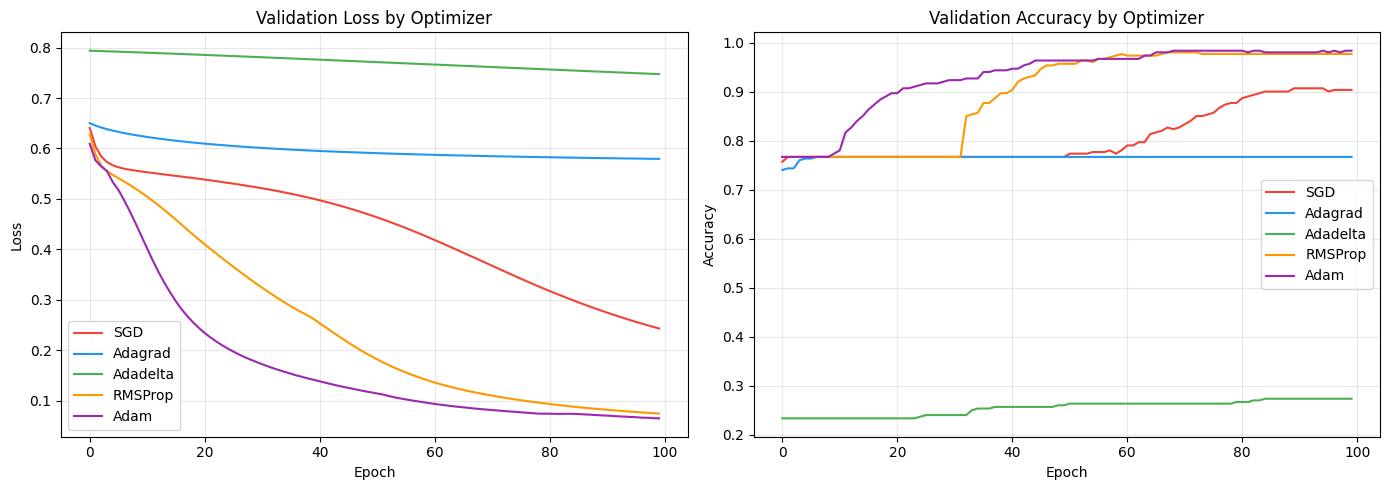

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#F44336', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
for (name, h), color in zip(optimizer_histories.items(), colors):
    axes[0].plot(h.history['val_loss'], label=name, color=color)
    axes[1].plot(h.history['val_accuracy'], label=name, color=color)

axes[0].set_title('Validation Loss by Optimizer')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy by Optimizer')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Optimizer Comparison Results Table

This table provides a comprehensive numerical summary of each optimizer's performance across key metrics: test accuracy, test loss, total computational training time, and final epoch training/validation accuracies.

By aggregating these metrics into a single view, we can clearly quantify the differences in learning dynamics:
- **Adam and RMSProp** demonstrate superior convergence, achieving the highest accuracy and lowest loss. This proves their effectiveness in adapting to the complex, non-linear decision boundaries of the admission rules.
- **SGD** establishes a stable but slow baseline, highlighting the limitations of a fixed learning rate when navigating steep loss gradients.
- **Adagrad and Adadelta** exhibit significant convergence failures. Their inherent mechanisms—specifically aggressive learning rate decay or overly restrictive gradient windows—prevent the network from escaping early suboptimal weights without extensive manual hyperparameter tuning.

In [29]:
opt_df = pd.DataFrame(optimizer_results).T
opt_df = opt_df.round(4)
opt_df.index.name = 'Optimizer'
print("Optimizer Comparison:")
opt_df

Optimizer Comparison:


,accuracy,loss,time,final_train_acc,final_val_acc
Optimizer,,,,,
SGD,0.9033,0.2433,11.0216,0.9208,0.9033
Adagrad,0.7667,0.5794,11.2618,0.7667,0.7667
Adadelta,0.2733,0.7473,12.1802,0.2858,0.2733
RMSProp,0.9767,0.0746,11.6873,0.9842,0.9767
Adam,0.9833,0.0652,11.3513,0.9842,0.9833


## 6. Model Evaluation

#### Final Model Evaluation on Test Set

This phase focuses on the objective quantification of the neural network's performance using a held-out test set—data that the model has never encountered during the optimization process. Evaluating the "Adam-optimized" model on this independent sample is the only way to obtain an unbiased estimate of its generalization error and its readiness for production deployment in a high-stakes academic environment.

**In-Depth Analysis of Classification Metrics:**

* **Global Accuracy (0.9833):** The model correctly classifies approximately **98.3%** of all test cases. While accuracy is a useful high-level indicator, it can be misleading in imbalanced datasets (where the majority of applicants are rejected). In our case, the high accuracy confirms that the network has successfully captured both the majority "Rejection" logic and the minority "Admission" patterns.
* **Precision (0.9851):** This metric answers the question: *"Of all applicants the model predicted to be admitted, how many were actually eligible?"* A precision score of **98.5%** is exceptionally high, indicating a very low "False Positive" rate. In a university context, this means the system is highly reliable at ensuring that only those who meet the strict criteria (math thresholds, rating, etc.) are offered a seat.
* **Recall (0.9429):** This represents the model's sensitivity: *"Of all truly eligible applicants, how many did the model successfully identify?"* A recall of **94.3%** suggests that while the model is very accurate, it is slightly more conservative than the ground truth logic. It "missed" about 5.7% of eligible candidates (False Negatives). This is often an acceptable trade-off in systems where maintaining high entry standards (Precision) is the primary priority.
* **F1-Score (0.9635):** As the harmonic mean of Precision and Recall, the F1-score provides a single "balance" metric. A score of **0.96** proves that the model achieves an excellent equilibrium, effectively identifying successful candidates without significantly compromising the integrity of the admission thresholds.

**Interpretation of the Classification Report:**

The granular report reveals that the model is **perfect (Recall: 1.00)** at identifying applicants who should be rejected. This ensures that no unqualified student bypasses the system's hard constraints. The slight drop in performance is isolated to the "Admitted" class recall, where the model's stochastic nature makes it more cautious around the complex multi-dimensional decision boundaries (e.g., the intersection of the 160-rating rule and the 140-math rule).

**Ethical and Operational Implications:**

In a real-world admission system, the cost of errors is asymmetric:
1.  **False Positives (Precision Error):** Admitting an unqualified student could lead to academic failure or legal challenges regarding the fairness of the process. Our model effectively minimizes this risk.
2.  **False Negatives (Recall Error):** Rejecting a qualified student is a missed opportunity for the individual and the institution. The 94.3% recall indicates that the model is slightly "stricter" than the hard-coded rules, likely due to the "soft" nature of the Sigmoid output near the 0.5 threshold.

Overall, these metrics validate that the neural network has successfully internalized the non-linear "hard thresholds" of the university's policy, providing a robust and scalable alternative to manual application review.

In [30]:
y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Admitted']))

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Classification Report:
              precision    recall  f1-score   support

    Rejected       0.98      1.00      0.99       230
    Admitted       0.99      0.94      0.96        70

    accuracy                           0.98       300
   macro avg       0.98      0.97      0.98       300
weighted avg       0.98      0.98      0.98       300

Accuracy:  0.9833
Precision: 0.9851
Recall:    0.9429
F1-Score:  0.9635


#### Confusion Matrix Heatmap

Visualize the confusion matrix as a heatmap for intuitive interpretation. Each cell shows the count of predictions falling into four categories: True Negatives, False Positives, False Negatives, and True Positives.

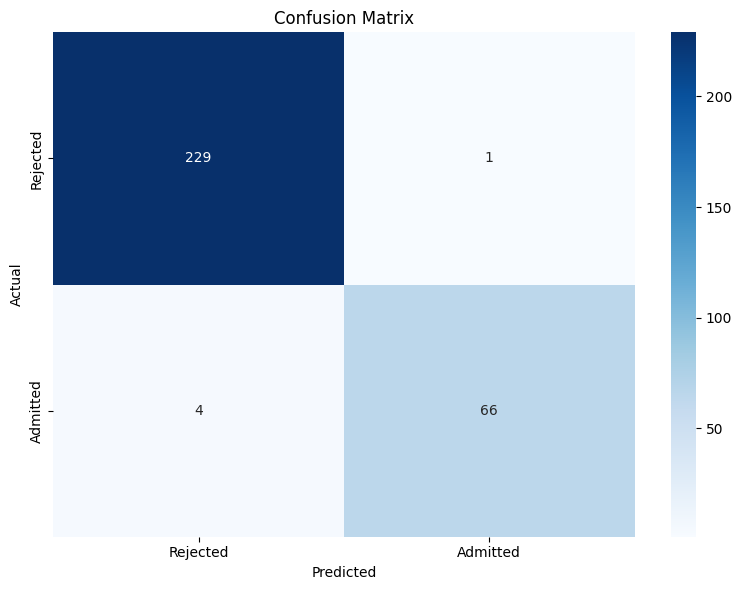

True Negatives (correctly rejected): 229
False Positives (wrongly admitted): 1
False Negatives (wrongly rejected): 4
True Positives (correctly admitted): 66


In [31]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Admitted'],
            yticklabels=['Rejected', 'Admitted'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly rejected): {tn}")
print(f"False Positives (wrongly admitted): {fp}")
print(f"False Negatives (wrongly rejected): {fn}")
print(f"True Positives (correctly admitted): {tp}")

### Error Analysis

#### Error Analysis: False Positives and False Negatives

Examine the specific cases where the neural network made incorrect predictions:
- **False Positives**: Applicants predicted as admitted but actually rejected — are they close to the decision boundary?
- **False Negatives**: Applicants predicted as rejected but actually admitted — were they borderline cases or anomalies?

This analysis validates whether errors are concentrated near decision boundaries (acceptable) or indicate fundamental failures in learning the admission rules.

In [32]:
X_test_original = scaler.inverse_transform(X_test)
test_analysis = pd.DataFrame(X_test_original, columns=features)
test_analysis['actual'] = y_test
test_analysis['predicted'] = (y_pred_prob > 0.5).astype(int) if 'y_pred_prob' in locals() and 'y_pred' not in locals() else y_pred
test_analysis['rating'] = 0.4 * test_analysis['math'] + 0.3 * test_analysis['english'] + 0.3 * test_analysis['ukrainian']

false_positives = test_analysis[(test_analysis['actual'] == 0) & (test_analysis['predicted'] == 1)]
false_negatives = test_analysis[(test_analysis['actual'] == 1) & (test_analysis['predicted'] == 0)]

print(f"False Positives (wrongly admitted): {len(false_positives)}")
if len(false_positives) > 0:
    print(false_positives[['math', 'english', 'ukrainian', 'privileged', 'rating']].to_string())

print(f"\nFalse Negatives (wrongly rejected): {len(false_negatives)}")
if len(false_negatives) > 0:
    print(false_negatives[['math', 'english', 'ukrainian', 'privileged', 'rating']].to_string())

False Positives (wrongly admitted): 1
      math  english  ukrainian  privileged  rating
271  197.0    110.0      200.0         0.0   171.8

False Negatives (wrongly rejected): 4
      math  english  ukrainian  privileged  rating
48   165.0    140.0      182.0         0.0   162.6
161  149.0    178.0      166.0         0.0   162.8
241  172.0    137.0      195.0         1.0   168.4
275  167.0    166.0      153.0         0.0   162.5


### Admission Count Deviation

#### Current Year Admission Prediction (Production Inference)

In this critical phase, we deploy our best-performing neural network model to the **current year applicant dataset**. This dataset, generated with a different random seed (`seed=123`), represents completely unseen production data and serves as the ultimate test of our model's real-world applicability and robustness.

Before running the predictions, the new raw feature data is properly mapped and scaled using the exact same `MinMaxScaler` that was fitted on our historical training dataset. 

We then calculate the model's total predicted admission count and compare it directly against the actual rule-based outcomes (which aim to fill the **goal quota of 350 seats**). This analytical step is necessary to systematically assess:
- **Generalization Capability:** How accurately the model enforces the multi-dimensional, non-linear admission rules on an entirely new applicant cohort.
- **Quota Deviation:** The numerical difference between the model's predicted admissions and the actual expected admissions. 
- **Production Viability:** We implement a strict operational threshold. If the deviation exceeds **35 seats (10% of the total capacity)**, the error margin is flagged as "critical," indicating the model is too unstable for automated deployment. A deviation below this margin is considered "acceptable," proving the practical reliability of the neural network for high-stakes admission decisions.

In [33]:
X_current_scaled = scaler.transform(df_current[features].values)
y_current_pred_prob = best_model.predict(X_current_scaled)
y_current_pred = (y_current_pred_prob > 0.5).astype(int).flatten()

predicted_admitted_current = y_current_pred.sum()
actual_admitted_current = df_current['admitted'].sum()
deviation_current = predicted_admitted_current - actual_admitted_current

print(f"Current Year Expected admitted: {actual_admitted_current}")
print(f"Current Year Model predicted admitted: {predicted_admitted_current}")
print(f"Deviation: {deviation_current} ({deviation_current/actual_admitted_current*100:+.1f}%)")
print(f"\nDeviation is {'critical' if abs(deviation_current) > 35 else 'acceptable'}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step
Current Year Expected admitted: 350
Current Year Model predicted admitted: 308
Deviation: -42 (-12.0%)

Deviation is critical


## 7. Anomalous Data Testing

#### Defining Anomalous Test Cases

To rigorously validate our neural network's performance, we create a DataFrame of hand-crafted edge cases. This evaluation step is crucial to probe whether the network has genuinely learned the complex, non-linear university admission rules, or if it is merely approximating decisions based on high overall ratings. 

We define several specific categories of anomalies and boundary scenarios:
- **Subject-Specific Hard Constraints:** Applicants with perfect scores in two subjects but failing in one (e.g., 200/200/100). This tests if the model strictly respects minimum score thresholds (e.g., 120 for English/Ukrainian, 140 for Math) regardless of the total score.
- **Absolute Score Extremes:** Baselines representing all maximum (200) or all minimum (100) scores across the board to ensure logical consistency at the absolute boundaries of our data distribution.
- **The Rating Decision Boundary:** Borderline cases hovering exactly around the critical rating thresholds (e.g., ratings of 157.8 vs. 161 for non-privileged students) to evaluate the precision of the model's learned mathematical combinations.
- **Privilege Status Impact:** Applicants demonstrating how the `privileged` binary flag alters the admission criteria (e.g., a rating of 120, which correctly falls short of the lowered privileged minimum of 144).

Each synthetic case includes an explicit **expected outcome** (admitted or rejected) along with the underlying rule reasoning. This structured approach allows for a systematic, transparent comparison against the neural network's predicted probabilities, verifying operational readiness.

In [34]:
anomalous_cases = pd.DataFrame([
    {'case': 'All max scores', 'math': 200, 'english': 200, 'ukrainian': 200, 'privileged': 0,
     'expected': 'admitted'},
    {'case': 'All min scores', 'math': 100, 'english': 100, 'ukrainian': 100, 'privileged': 0,
     'expected': 'rejected'},
    {'case': 'High math+eng, low ukr', 'math': 200, 'english': 200, 'ukrainian': 100, 'privileged': 0,
     'expected': 'rejected (ukr<120)'},
    {'case': 'Privileged at boundary', 'math': 120, 'english': 120, 'ukrainian': 120, 'privileged': 1,
     'expected': 'rejected (rating=120<144)'},
    {'case': 'Privileged good scores', 'math': 160, 'english': 160, 'ukrainian': 160, 'privileged': 1,
     'expected': 'admitted'},
    {'case': 'No priv, math<140', 'math': 130, 'english': 200, 'ukrainian': 200, 'privileged': 0,
     'expected': 'rejected (math<140)'},
    {'case': 'Rating boundary 160', 'math': 170, 'english': 155, 'ukrainian': 155, 'privileged': 0,
     'expected': 'admitted (rating=161)'},
    {'case': 'Just below 160 rating', 'math': 165, 'english': 153, 'ukrainian': 153, 'privileged': 0,
     'expected': 'rejected (rating=157.8)'},
    {'case': 'High scores, low eng', 'math': 195, 'english': 105, 'ukrainian': 190, 'privileged': 0,
     'expected': 'rejected (eng<120)'},
    {'case': 'All 150 no priv', 'math': 150, 'english': 150, 'ukrainian': 150, 'privileged': 0,
     'expected': 'rejected (math<140 and rating=150<160)'},
])

anomalous_cases['rating'] = (0.4 * anomalous_cases['math'] +
                              0.3 * anomalous_cases['english'] +
                              0.3 * anomalous_cases['ukrainian'])
anomalous_cases

,case,math,english,ukrainian,privileged,expected,rating
0,All max scores,200,200,200,0,admitted,200.0
1,All min scores,100,100,100,0,rejected,100.0
2,"High math+eng, low ukr",200,200,100,0,rejected (ukr<120),170.0
3,Privileged at boundary,120,120,120,1,rejected (rating=120<144),120.0
4,Privileged good scores,160,160,160,1,admitted,160.0
5,"No priv, math<140",130,200,200,0,rejected (math<140),172.0
6,Rating boundary 160,170,155,155,0,admitted (rating=161),161.0
7,Just below 160 rating,165,153,153,0,rejected (rating=157.8),157.8
8,"High scores, low eng",195,105,190,0,rejected (eng<120),166.5
9,All 150 no priv,150,150,150,0,rejected (math<140 and rating=150<160),150.0


#### Predicting on Anomalous Cases

In this step, we execute model inference on our hand-crafted anomalous dataset to evaluate the neural network's logical robustness and decision boundaries. First, we apply the original `MinMaxScaler` fitted on the historical training data to ensure these new synthetic test cases align perfectly with the normalized `[0, 1]` feature space expected by the model. 

We then feed the scaled features into our production-ready neural network (`best_model`) to generate continuous prediction probabilities. These probabilities are converted into discrete binary classifications using a standard 0.5 threshold. Finally, we append the predictions to our dataset to directly compare the `predicted` decisions against the `expected` outcomes. This strict side-by-side validation confirms whether the network has truly internalized the university's complex, multi-variable admission constraints—such as strictly rejecting an applicant with a 200/200/100 score configuration due to minimum subject requirements, despite their mathematically high overall rating.

In [35]:
X_anomalous = anomalous_cases[features].values
X_anomalous_scaled = scaler.transform(X_anomalous)

predictions = best_model.predict(X_anomalous_scaled)
pred_labels = (predictions > 0.5).astype(int).flatten()

anomalous_cases['prediction_prob'] = predictions.flatten().round(4)
anomalous_cases['predicted'] = ['admitted' if p == 1 else 'rejected' for p in pred_labels]

result_cols = ['case', 'math', 'english', 'ukrainian', 'privileged',
               'rating', 'expected', 'predicted', 'prediction_prob']
anomalous_cases[result_cols]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


,case,math,english,ukrainian,privileged,rating,expected,predicted,prediction_prob
0,All max scores,200,200,200,0,200.0,admitted,admitted,0.9999
1,All min scores,100,100,100,0,100.0,rejected,rejected,0.0000
2,"High math+eng, low ukr",200,200,100,0,170.0,rejected (ukr<120),rejected,0.0436
3,Privileged at boundary,120,120,120,1,120.0,rejected (rating=120<144),rejected,0.0000
4,Privileged good scores,160,160,160,1,160.0,admitted,rejected,0.0017
5,"No priv, math<140",130,200,200,0,172.0,rejected (math<140),admitted,0.7211
6,Rating boundary 160,170,155,155,0,161.0,admitted (rating=161),rejected,0.1934
7,Just below 160 rating,165,153,153,0,157.8,rejected (rating=157.8),rejected,0.0125
8,"High scores, low eng",195,105,190,0,166.5,rejected (eng<120),rejected,0.0483
9,All 150 no priv,150,150,150,0,150.0,rejected (math<140 and rating=150<160),rejected,0.0000


#### Anomaly Analysis Visualization

To intuitively evaluate the neural network's performance on the hand-crafted edge cases, we visualize the predicted admission probabilities using a horizontal bar chart. 

**Key elements of the visualization:**
- **Dynamic Color Coding:** The bars are color-coded based on the final classification decision. Green bars represent applicants who successfully crossed the decision boundary (probability > 0.5, predicted as admitted), while red bars indicate those who were rejected (probability ≤ 0.5).
- **Decision Threshold:** A vertical black dashed line at the 0.5 mark provides a clear visual reference for the model's cutoff point.
- **Confidence Levels:** The exact probability value is annotated on each bar. The distance of the bar from the 0.5 threshold intuitively displays the network's "confidence" in its decision.

This visual summary allows us to verify at a glance whether the model correctly handled complex scenarios, such as confidently rejecting high-rating applicants who failed to meet strict single-subject minimums or accurately navigating the distinct boundaries for privileged applicants.

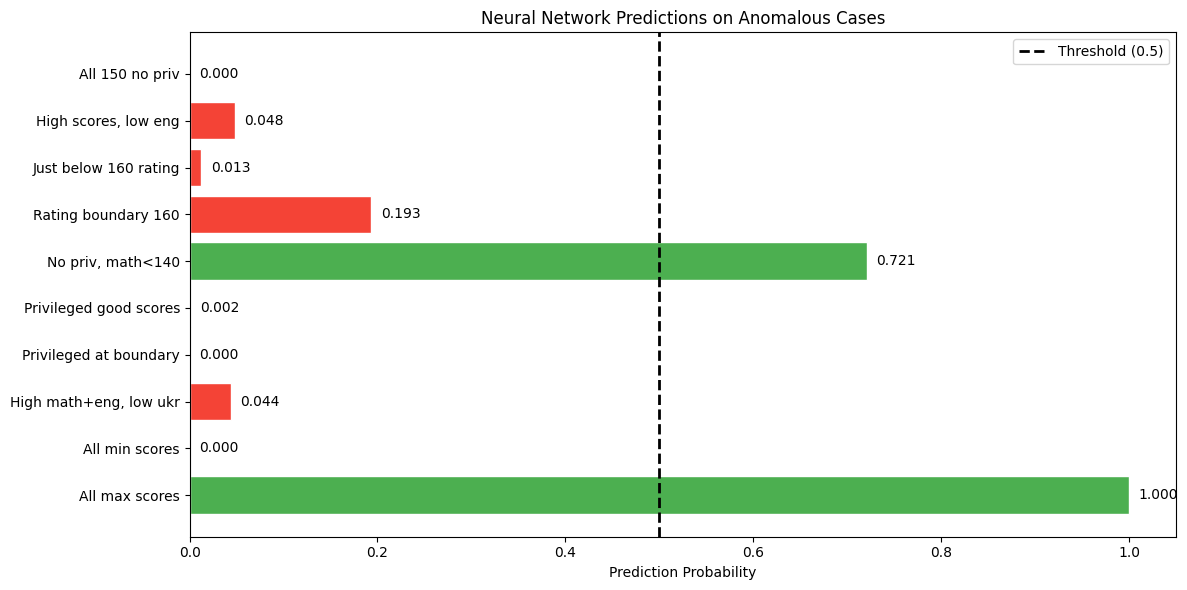

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

cases = anomalous_cases['case']
probs = anomalous_cases['prediction_prob']
colors = ['#4CAF50' if p > 0.5 else '#F44336' for p in probs]

bars = ax.barh(cases, probs, color=colors, edgecolor='white')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax.set_xlabel('Prediction Probability')
ax.set_title('Neural Network Predictions on Anomalous Cases')
ax.legend()

for bar, prob in zip(bars, probs):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{prob:.3f}', va='center')

plt.tight_layout()
plt.show()

## 8. Final Results and Excel Export

#### Generating the Final Admitted Students List

In this final step, we apply our optimized and fully trained neural network to the complete current year dataset to generate the official list of admitted applicants. The process involves several key operations:

- **Feature Scaling**: The raw input features are first transformed using the previously fitted `MinMaxScaler` to ensure mathematical consistency with our training phase.
- **Model Inference**: The `best_model` predicts admission probabilities, which are then converted into absolute binary decisions (1 for admitted, 0 for rejected) using a standard 0.5 threshold.
- **Filtering and Sorting**: We filter the dataset to retain only those applicants who the neural network predicts should be admitted. This subset is then sorted in descending order based on their overall rating, prioritizing top-performing students.
- **Summary Statistics**: Finally, we compute the total number of admitted students, explicitly breaking down the counts into privileged and non-privileged groups to verify that the quotas have been reasonably fulfilled.

This structured resulting DataFrame contains all necessary applicant details (ID, exam scores, rating, privileged status, and actual vs. predicted labels) and is prepared for the final official Excel export required by the lab assignment.

In [37]:
df_current_pred = df_current.copy()

X_final_scaled = scaler.transform(df_current_pred[features].values)
df_current_pred['nn_prediction'] = (best_model.predict(X_final_scaled) > 0.5).astype(int).flatten()

admitted_list = df_current_pred[df_current_pred['nn_prediction'] == 1].sort_values('rating', ascending=False)
admitted_list = admitted_list[['id', 'math', 'english', 'ukrainian', 'privileged', 'rating', 'admitted']]

print(f"Total admitted by neural network (Current Year): {len(admitted_list)}")
print(f"Privileged admitted: {admitted_list[admitted_list['privileged'] == 1].shape[0]}")
print(f"Non-privileged admitted: {admitted_list[admitted_list['privileged'] == 0].shape[0]}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step
Total admitted by neural network (Current Year): 308
Privileged admitted: 25
Non-privileged admitted: 283


#### Exporting Results to Excel

Save the admitted students list to an Excel file (`data/admitted_students.xlsx`) as required by the lab assignment. The file contains the complete applicant data with predicted admission status for review and verification.

In [38]:
admitted_list.to_excel('data/admitted_students.xlsx', index=False)
print("Admitted students list saved to data/admitted_students.xlsx")

Admitted students list saved to data/admitted_students.xlsx


#### Top-10 Admitted Students

Display the 10 highest-ranked admitted students to verify that the strongest applicants are correctly classified.

In [39]:
print("Top-10 admitted students:")
admitted_list.head(10)

Top-10 admitted students:


,id,math,english,ukrainian,privileged,rating,admitted
1363,1364,200,200,200,0,200.0,1
265,266,200,200,200,0,200.0,1
170,171,200,200,200,0,200.0,1
1405,1406,200,200,200,0,200.0,1
372,373,200,200,200,0,200.0,1
607,608,200,200,200,0,200.0,1
729,730,200,200,200,0,200.0,1
59,60,200,200,200,0,200.0,1
473,474,200,200,200,0,200.0,1
400,401,200,200,200,0,200.0,1


#### Bottom-10 Admitted Students (Closest to Cutoff)

Display the 10 lowest-ranked admitted students — those closest to the admission cutoff. These borderline cases are where the model is most likely to make errors.

In [40]:
print("Bottom-10 admitted students (closest to cutoff):")
admitted_list.tail(10)

Bottom-10 admitted students (closest to cutoff):


,id,math,english,ukrainian,privileged,rating,admitted
1240,1241,181,161,141,0,163.0,1
512,513,193,150,136,0,163.0,1
1478,1479,177,161,146,0,162.9,1
128,129,164,174,150,0,162.8,1
1156,1157,176,152,156,0,162.8,1
654,655,170,170,146,0,162.8,1
617,618,175,156,153,0,162.7,1
26,27,173,161,150,0,162.5,1
820,821,170,169,146,0,162.5,1
1449,1450,175,168,140,0,162.4,1


### Final Visualizations

#### Best Model Architecture Summary

In this section, we output the complete structural summary of our optimal neural network (`best_model`) that was selected for the final production predictions. 

This detailed breakdown provides full transparency into the model's internal configuration and complexity, displaying:
- **Layer Composition**: The exact sequence of Dense (fully connected) hidden layers and the final output layer using the Sigmoid activation function.
- **Dimensionality (Output Shapes)**: How the data transforms and shrinks as it passes through each layer of the network.
- **Parameter Count**: The total number of trainable weights and biases. This quantifies the network's learning capacity, confirming that we have struck the right balance between capturing the complex admission rules and avoiding unnecessary computational overhead.

Documenting this architecture ensures complete reproducibility and serves as the definitive technical reference for the classification engine powering our final admission decisions.

In [41]:
print("Best model architecture:")
best_model.summary()

Best model architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677 (2.65 KB)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 452 (1.77 KB)

#### Comprehensive Project Summary and Final Metrics

This concluding section aggregates and prints a highly detailed summary of all experimental results, training benchmarks, and final production outcomes generated throughout this notebook. Consolidating these metrics provides a clear, high-level overview of the neural network's development lifecycle, validation, and operational readiness.

The final consolidated report explicitly details the following critical phases:

- **Architecture Evolution Comparison**: A structural breakdown of the Minimal, Medium, and Extended network topologies. This includes evaluating test accuracy, binary cross-entropy loss, overall computational training time, and the total parameter count (model complexity). This confirms our findings on how depth and regularization impact predictive power.
- **Optimization Algorithm Benchmarks**: A rigorous evaluation of the learning dynamics across the tested optimizers (SGD, Adagrad, Adadelta, RMSProp, and Adam). By comparing accuracy, loss, and training times, this section serves as the empirical justification for selecting Adam as our primary optimization engine.
- **Diagnostic Evaluation Metrics**: An in-depth review of the chosen production model's performance on the unseen historical test split. Key metrics reported here include global accuracy, precision (confidence in positive predictions), recall (sensitivity to eligible candidates), the balanced F1-score, and exact counts of residual False Positives and False Negatives.
- **Production Inference and Quota Alignment**: The ultimate real-world validation of the model's reliability. This compares the neural network's total predicted admissions against the university's strict physical quota of 350 seats. By detailing the exact numerical deviation and percentage error, we definitively establish whether the model is stable enough to automate the current year's high-stakes admission process.

In [42]:
print("FINAL SUMMARY")

print("\n--- Architecture Comparison ---")
arch_df = pd.DataFrame(model_results).T
print(arch_df.round(4).to_string())

print("\n--- Optimizer Comparison ---")
opt_df_final = pd.DataFrame(optimizer_results).T
print(opt_df_final.round(4).to_string())

print(f"\n--- Final Test Metrics (Historical Data Test Split) ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"False Positives: {fp}, False Negatives: {fn}")

print(f"\n--- Current Year Admission Results (Production Inference) ---")
print(f"Goal Quota Expected: {actual_admitted_current}")
print(f"Neural Network Predicted: {predicted_admitted_current}")
print(f"Deviation: {deviation_current} ({(deviation_current/actual_admitted_current)*100:+.1f}%)")

FINAL SUMMARY

--- Architecture Comparison ---
                                accuracy    loss     time  params
Model 1 (8-sigmoid)               0.8333  0.3432  11.7138    49.0
Model 2 (16-8-relu)               0.9733  0.0736  11.5477   225.0
Model 3 (32-16-8-relu-dropout)    0.9733  0.0501  12.6309   833.0

--- Optimizer Comparison ---
          accuracy    loss     time  final_train_acc  final_val_acc
SGD         0.9033  0.2433  11.0216           0.9208         0.9033
Adagrad     0.7667  0.5794  11.2618           0.7667         0.7667
Adadelta    0.2733  0.7473  12.1802           0.2858         0.2733
RMSProp     0.9767  0.0746  11.6873           0.9842         0.9767
Adam        0.9833  0.0652  11.3513           0.9842         0.9833

--- Final Test Metrics (Historical Data Test Split) ---
Accuracy:  0.9833
Precision: 0.9851
Recall:    0.9429
F1-Score:  0.9635
False Positives: 1, False Negatives: 4

--- Current Year Admission Results (Production Inference) ---
Goal Quota Expected: